In [102]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))
plt.rcParams["figure.figsize"] = (12, 5)

In [ ]:
from src.ddb_client import connect_ddb

s = connect_ddb()

df = s.run("""
select *
from loadTable("dfs://quota","qtick")
where code = "000009.SZ"
and date >= 2026.03.11
and date <= 2026.03.30
""")


In [ ]:
# standardize time column to datetime and sort the dataframe by time
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

# 9:15-9:30
df = df[
    (df["time"].dt.time >= pd.to_datetime("09:15:00").time()) &
    (df["time"].dt.time <= pd.to_datetime("09:30:00").time())
].copy()

In [ ]:
# fair price (mid price)
df["mid_price"] = (df["bp0"] + df["ap0"]) / 2

# market execution price (trade price)
df["trade_price"] = df["new_price"]

# mid price (baseline)
df["mid"] = (df["bp0"] + df["ap0"]) / 2

# spread
df["spread"] = df["ap0"] - df["bp0"]

# microprice (IMPORTANT UPGRADE)
df["microprice"] = (
    df["bp0"] * df["av0"] + df["ap0"] * df["bv0"]
) / (df["bv0"] + df["av0"] + 1e-9)

# depth
df["bid_vol"] = df[[f"bv{i}" for i in range(10)]].sum(axis=1)
df["ask_vol"] = df[[f"av{i}" for i in range(10)]].sum(axis=1)

# imbalance (KEY VARIABLE)
df["imbalance"] = (df["bid_vol"] - df["ask_vol"]) / (df["bid_vol"] + df["ask_vol"] + 1e-9)

In [109]:
def label_phase(t):
    t = t.time()
    if t < pd.to_datetime("09:20:00").time():
        return "9:15-9:20 (Order Submission)"
    elif t < pd.to_datetime("09:25:00").time():
        return "9:20-9:25 (Order Matching Build-up)"
    else:
        return "9:25-9:30 (Opening Auction Fix)"

df["phase"] = df["time"].apply(label_phase)

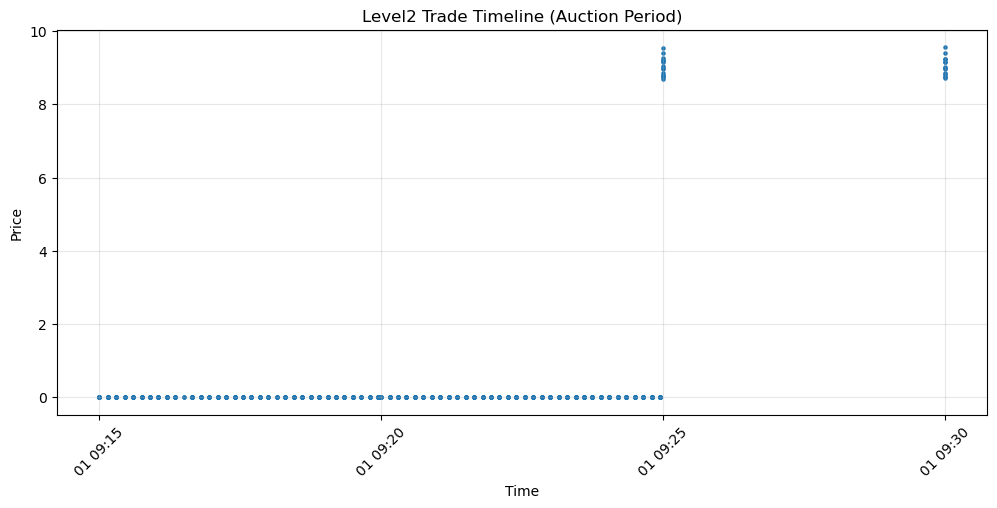

In [124]:
# 成交时间轴图
plt.scatter(df["time"], df["trade_price"], s=5)

plt.title("Level2 Trade Timeline (Auction Period)")
plt.xlabel("Time")
plt.ylabel("Price")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

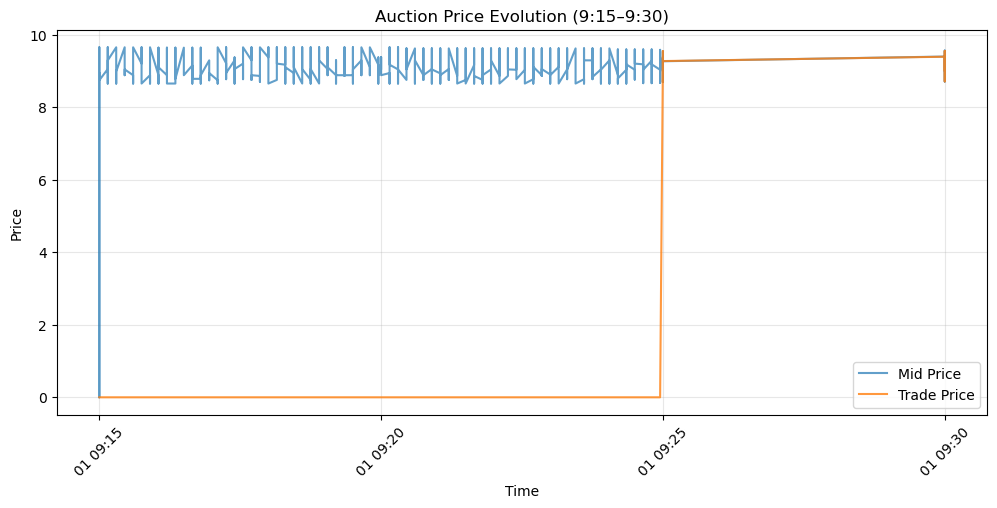

In [ ]:
# 样例股票集合竞价价格变化图
plt.plot(df["time"], df["mid_price"], label="Mid Price", alpha=0.7)
plt.plot(df["time"], df["trade_price"], label="Trade Price", alpha=0.8)

plt.title("Auction Price Evolution (9:15–9:30)")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

In [125]:
auction_df = df[df["phase"] == "auction fix"]

auction_price = auction_df["mid"].iloc[-1]

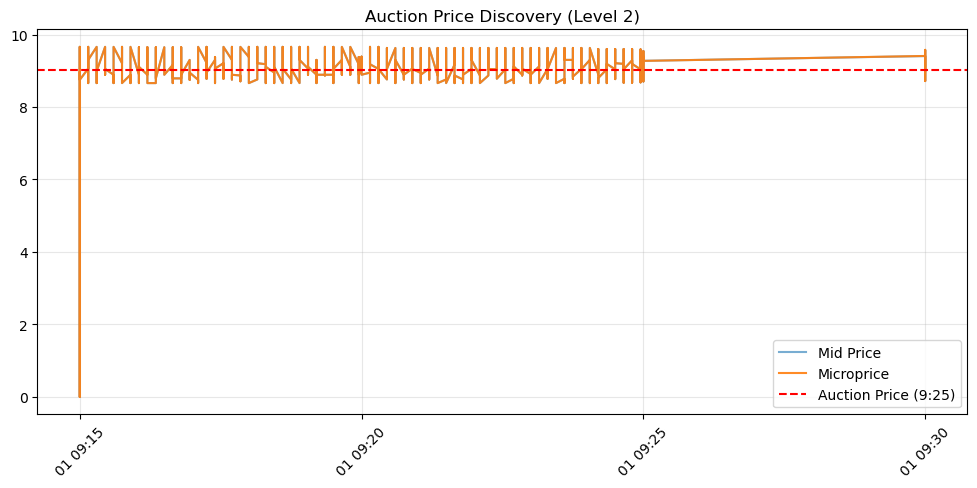

In [126]:
plt.figure()

plt.plot(df["time"], df["mid"], label="Mid Price", alpha=0.6)
plt.plot(df["time"], df["microprice"], label="Microprice", alpha=0.9)

plt.axhline(auction_price, color="red", linestyle="--", label="Auction Price (9:25)")

plt.title("Auction Price Discovery (Level 2)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.show()

In [ ]:
# 委托量变化图
bid_cols = [c for c in df.columns if "bv" in c]
ask_cols = [c for c in df.columns if "av" in c]

df["bid_volume"] = df[bid_cols].sum(axis=1)
df["ask_volume"] = df[ask_cols].sum(axis=1)

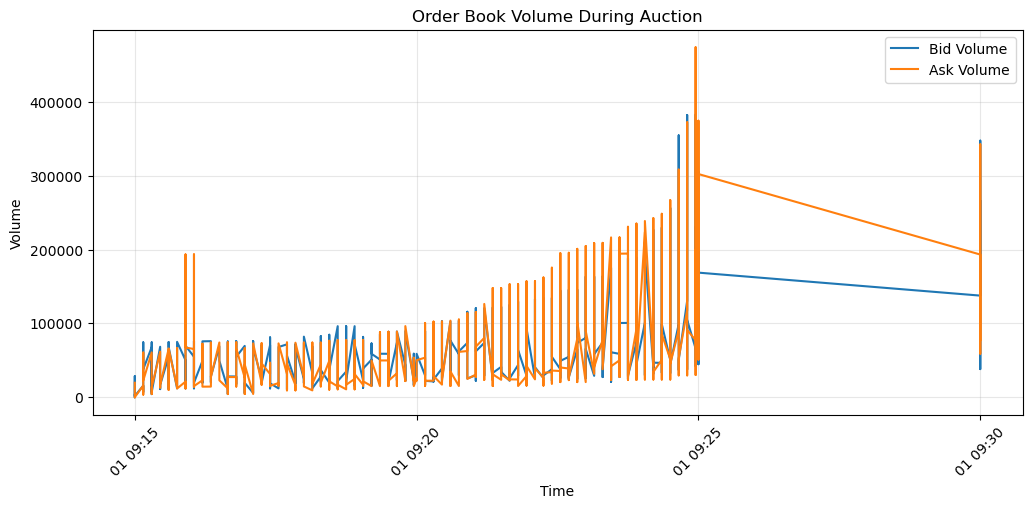

In [116]:
plt.plot(df["time"], df["bid_volume"], label="Bid Volume")
plt.plot(df["time"], df["ask_volume"], label="Ask Volume")

plt.title("Order Book Volume During Auction")
plt.xlabel("Time")
plt.ylabel("Volume")

plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

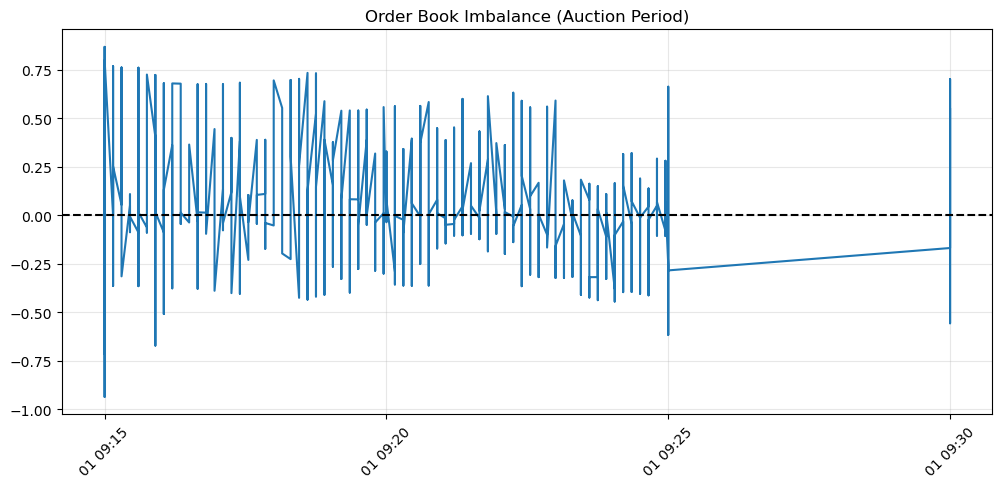

In [117]:
plt.figure()

plt.plot(df["time"], df["imbalance"])
plt.axhline(0, color="black", linestyle="--")

plt.title("Order Book Imbalance (Auction Period)")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.show()

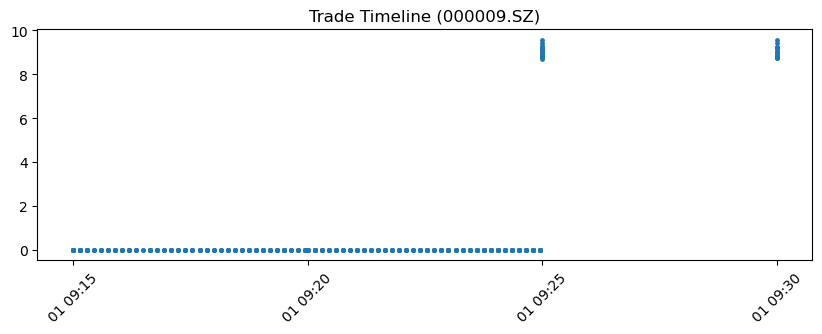

In [118]:
# 交易时间轴图
import matplotlib.pyplot as plt
plt.figure(figsize=(10,3))

plt.scatter(df["time"], df["trade_price"], s=6)

plt.title("Trade Timeline (000009.SZ)")
plt.xticks(rotation=45)

plt.show()

| 时间段       | 含义              | 行为                 |
| --------- | --------------- | ------------------ |
| 9:15–9:20 | early auction   | 撤单+试探报价            |
| 9:20–9:25 | locked phase    | 不可撤单 + 意愿聚集        |
| 9:24–9:25 | pre-close build | order imbalance 形成 |
| 9:25      | match           | auction price 形成   |
| 9:25–9:30 | stabilization   | 撮合后微调              |


In [119]:
# 集合竞价价格变化
df["minute"] = df["time"].dt.floor("min")
df2 = df[df["time"] >= "09:25:00"]

price_trade = df2.groupby("minute")["trade_price"].last()
price_mid = df.groupby("minute")["mid_price"].mean()

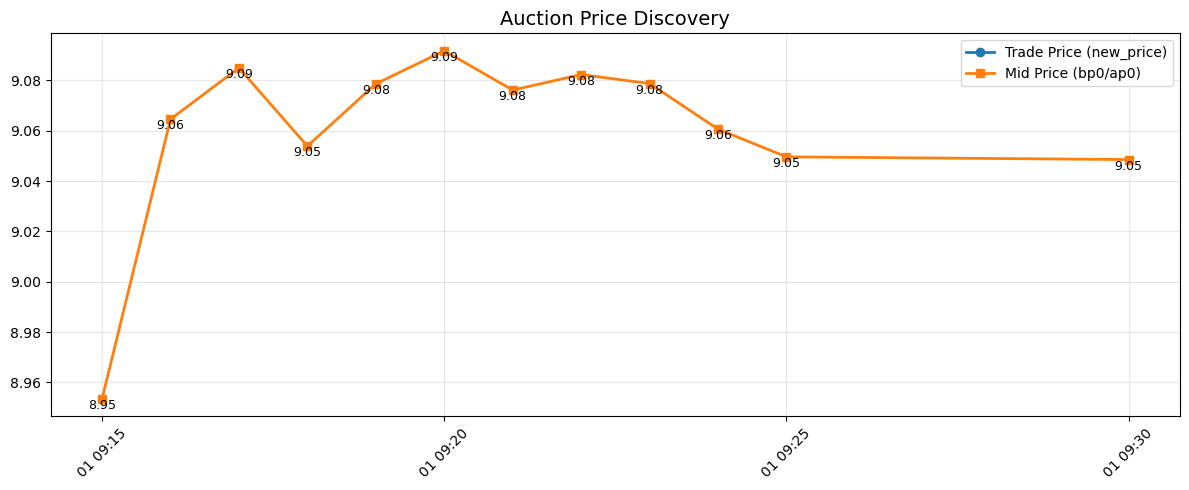

In [121]:
plt.figure(figsize=(12,5))

plt.plot(price_trade.index, price_trade.values,
         marker="o", markersize=6,
         linewidth=2,
         label="Trade Price (new_price)")

plt.plot(price_mid.index, price_mid.values,
         marker="s", markersize=6,
         linewidth=2,
         label="Mid Price (bp0/ap0)")

plt.title("Auction Price Discovery", fontsize=14)
plt.legend()


ymin = min(price_trade.min(), price_mid.min())
ymax = max(price_trade.max(), price_mid.max())


step = 1  

for i in range(0, len(price_trade), step):
    plt.text(price_trade.index[i],
             price_trade.values[i],
             f"{price_trade.values[i]:.2f}",
             fontsize=9,
             color="blue",
             ha="center",
             va="bottom")

for i in range(0, len(price_mid), step):
    plt.text(price_mid.index[i],
             price_mid.values[i],
             f"{price_mid.values[i]:.2f}",
             fontsize=9,
             color="black",
             ha="center",
             va="top")


plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [122]:
# 委托量变化
bid_cols = [f"bv{i}" for i in range(10)]
ask_cols = [f"av{i}" for i in range(10)]

df["bid_vol"] = df[bid_cols].sum(axis=1)
df["ask_vol"] = df[ask_cols].sum(axis=1)

bid = df.groupby("minute")["bid_vol"].sum()
ask = df.groupby("minute")["ask_vol"].sum()

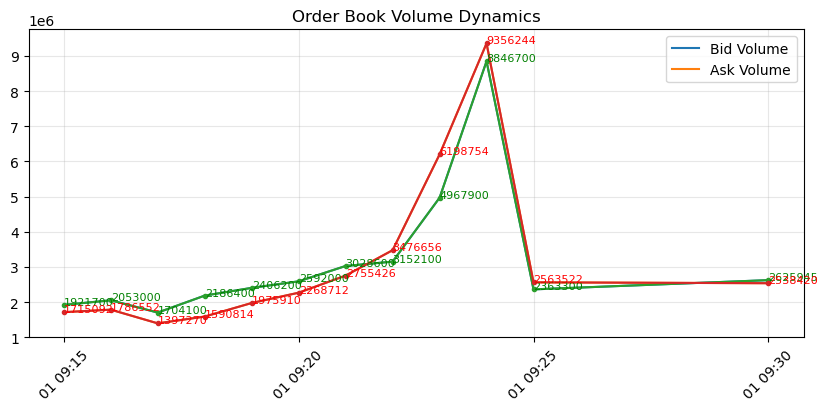

In [123]:
plt.figure(figsize=(10,4))

plt.plot(bid.index, bid.values, label="Bid Volume")
plt.plot(ask.index, ask.values, label="Ask Volume")

plt.title("Order Book Volume Dynamics")
plt.legend()
plt.xticks(rotation=45)

interval = 1

for i in range(0, len(bid), interval):
    plt.text(bid.index[i], bid.values[i], str(int(bid.values[i])),
             fontsize=8, color="green")

    plt.text(ask.index[i], ask.values[i], str(int(ask.values[i])),
             fontsize=8, color="red")

plt.plot(bid.index, bid.values, marker="o", markersize=3)
plt.plot(ask.index, ask.values, marker="o", markersize=3)

plt.grid(True, alpha=0.3)
plt.show()